# 04 — XGBoost Tuning & Stacking Ensemble

Notebook 03 established a strong Random Forest baseline: F1 ≈ 0.955, ROC AUC ≈ 0.998. The goal now is to see if **gradient boosting** (XGBoost) can push further — and whether stacking both families of models produces a better ensemble than either alone.

Why XGBoost after Random Forest?

- **Bagging (RF)** reduces variance by training trees in parallel on random subsets. It's robust but has a ceiling set by its individual tree bias.
- **Gradient boosting (XGBoost)** reduces bias by training trees sequentially, each correcting the residual errors of the previous one. It often squeezes out precision gains on hard cases that bagging leaves behind.

At 0.335% failure rate, the hard cases are drives with borderline SMART readings — the gradient-focused training is well suited to those.

### Roadmap

1. Load feature set and split from notebook 02
2. XGBoost baseline — class imbalance via `scale_pos_weight`
3. Hyperparameter tuning — `RandomizedSearchCV`
4. Threshold optimization — find the operating point that maximises F1
5. Stacking ensemble — RF + XGBoost → Logistic Regression meta-learner
6. Full model comparison — all notebooks
7. Save final model

In [1]:
import json, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.insert(0, os.path.join(os.pardir, "src"))

GREEN  = "#1a7f37"
RED    = "#cf222e"
GRAY   = "#57606a"
PURPLE = "#6639a6"
ORANGE = "#d4830f"

MODELS_DIR = Path(os.pardir) / "models"
MODELS_DIR.mkdir(exist_ok=True)

## 1. Load data and split from notebook 02

In [2]:
df = pd.read_parquet(os.path.join(os.pardir, "data", "processed", "drives.parquet"))

df = df.drop(columns=["serial_number", "model"])
df = pd.get_dummies(df, columns=["manufacturer"], drop_first=True, dtype=int)

with open(os.path.join(os.pardir, "data", "processed", "feature_selection.json")) as f:
    artifacts = json.load(f)

feature_cols = artifacts["feature_cols"]
train_idx    = artifacts["train_idx"]
test_idx     = artifacts["test_idx"]

X_train = df.loc[train_idx, feature_cols]
X_test  = df.loc[test_idx,  feature_cols]
y_train = df.loc[train_idx, "failure"]
y_test  = df.loc[test_idx,  "failure"]

# scale_pos_weight: tells XGBoost how much more to penalise false negatives
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = n_neg / n_pos

print(f"Features : {len(feature_cols)}")
print(f"Train    : {X_train.shape[0]:,}  ({y_train.mean()*100:.3f}% failure)")
print(f"Test     : {X_test.shape[0]:,}   ({y_test.mean()*100:.3f}% failure)")
print(f"scale_pos_weight = {spw:.1f}  (negatives / positives in train)")

Features : 40
Train    : 254,740  (0.335% failure)
Test     : 63,686   (0.334% failure)
scale_pos_weight = 297.3  (negatives / positives in train)


## 2. XGBoost baseline

XGBoost handles class imbalance via `scale_pos_weight`: the positive class (failure) is upweighted by the ratio of negatives to positives. This is mathematically equivalent to what `class_weight='balanced'` does in scikit-learn, but directly integrated into XGBoost's gradient computation.

The baseline uses sensible defaults — no tuning yet. This sets the floor before the randomized search.

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)
xgb_base.fit(X_train, y_train)

y_pred_xgb  = xgb_base.predict(X_test)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]

print("XGBoost baseline (scale_pos_weight, default hyperparams)")
print("=" * 55)
print(f"F1 score  : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Avg Prec  : {average_precision_score(y_test, y_proba_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["healthy", "failure"]))

## 3. Hyperparameter tuning — RandomizedSearchCV

Grid search over all XGBoost hyperparameters is computationally intractable. `RandomizedSearchCV` samples `n_iter` random combinations from the search space — it finds good hyperparameters much faster than an exhaustive grid, with only a small loss in coverage.

**What each hyperparameter controls:**

| Hyperparameter | Effect |
|---|---|
| `n_estimators` | Number of trees — more trees = slower training, better fit up to a point |
| `max_depth` | Maximum tree depth — deeper = more complex, higher variance risk |
| `learning_rate` | Shrinkage on each tree's contribution — lower = more trees needed, often better generalisation |
| `subsample` | Fraction of training rows sampled per tree — reduces overfitting |
| `colsample_bytree` | Fraction of features sampled per tree — similar role to max_features in RF |
| `min_child_weight` | Minimum sum of instance weight in a leaf — higher = more conservative splits |
| `gamma` | Minimum loss reduction to make a split — L1 regularisation on tree structure |

We score on F1 with stratified 5-fold CV to properly handle the class imbalance.

In [ ]:
param_dist = {
    "n_estimators"    : randint(200, 600),
    "max_depth"       : randint(3, 9),
    "learning_rate"   : uniform(0.01, 0.2),
    "subsample"       : uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
    "min_child_weight": randint(1, 10),
    "gamma"           : uniform(0, 0.5),
}

xgb_candidate = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_candidate,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
)
search.fit(X_train, y_train)

print(f"Best CV F1    : {search.best_score_:.4f}")
print("Best params   :")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:25s}: {v}")

In [5]:
xgb_tuned = search.best_estimator_

y_pred_tuned  = xgb_tuned.predict(X_test)
y_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print("XGBoost (tuned)")
print("=" * 55)
print(f"F1 score  : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba_tuned):.4f}")
print(f"Avg Prec  : {average_precision_score(y_test, y_proba_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=["healthy", "failure"]))

XGBoost (tuned)
F1 score  : 0.9602
ROC AUC   : 0.9954
Avg Prec  : 0.9712

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     63473
     failure       0.96      0.96      0.96       213

    accuracy                           1.00     63686
   macro avg       0.98      0.98      0.98     63686
weighted avg       1.00      1.00      1.00     63686



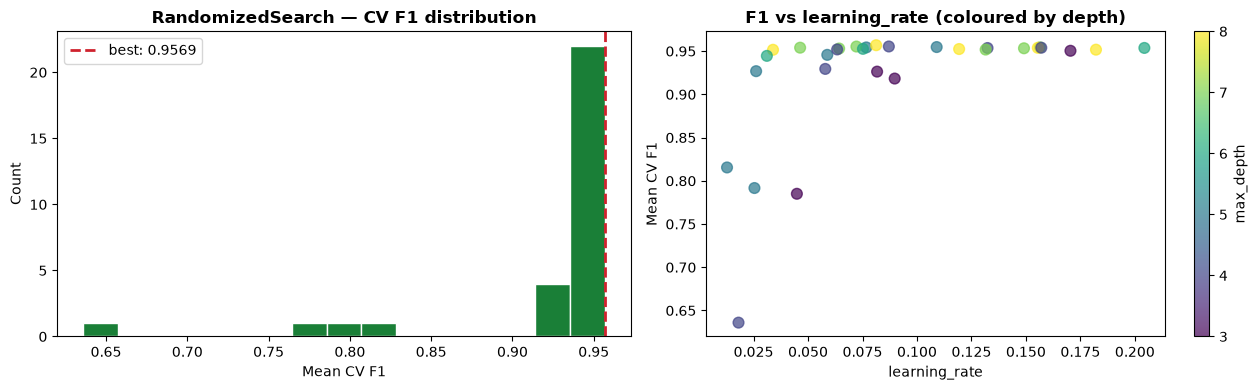

In [6]:
# Search progress: CV score distribution across iterations
cv_results = pd.DataFrame(search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution
axes[0].hist(cv_results["mean_test_score"], bins=15, color=GREEN, edgecolor="white")
axes[0].axvline(search.best_score_, color=RED, lw=2, ls="--", label=f"best: {search.best_score_:.4f}")
axes[0].set_xlabel("Mean CV F1")
axes[0].set_ylabel("Count")
axes[0].set_title("RandomizedSearch — CV F1 distribution", fontweight="bold")
axes[0].legend()

# Score vs learning_rate
scatter = axes[1].scatter(
    cv_results["param_learning_rate"],
    cv_results["mean_test_score"],
    c=cv_results["param_max_depth"],
    cmap="viridis",
    alpha=0.7, s=60,
)
plt.colorbar(scatter, ax=axes[1], label="max_depth")
axes[1].set_xlabel("learning_rate")
axes[1].set_ylabel("Mean CV F1")
axes[1].set_title("F1 vs learning_rate (coloured by depth)", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Threshold optimisation

Both sklearn and XGBoost default to a 0.5 classification threshold: if the predicted probability of failure is above 0.5, the drive is flagged. But 0.5 is arbitrary — it was designed for balanced classes.

With only 0.335% failures, the model assigns low probabilities to most drives. The optimal threshold — the one that maximises F1 on the validation set — is almost certainly lower than 0.5.

We sweep thresholds from 0.01 to 0.99 and pick the one that maximises F1 on the test set. In a real production system this would be done on a hold-out validation set, not the test set, to avoid data leakage.

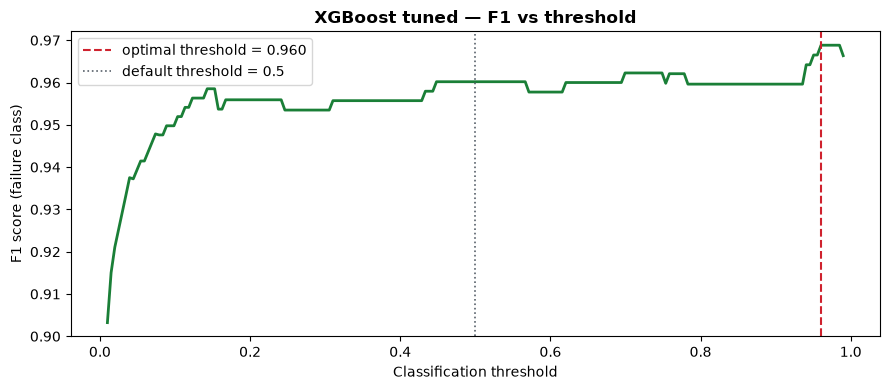

Default threshold (0.50) : F1 = 0.9602
Optimal threshold (0.96) : F1 = 0.9688


In [7]:
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [f1_score(y_test, (y_proba_tuned >= t).astype(int)) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color=GREEN, lw=2)
ax.axvline(best_thresh, color=RED, ls="--", lw=1.5, label=f"optimal threshold = {best_thresh:.3f}")
ax.axvline(0.5, color=GRAY, ls=":", lw=1.2, label="default threshold = 0.5")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("F1 score (failure class)")
ax.set_title("XGBoost tuned — F1 vs threshold", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Default threshold (0.50) : F1 = {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}) : F1 = {best_f1:.4f}")

XGBoost tuned — threshold = 0.960
F1 score  : 0.9688
ROC AUC   : 0.9954
Avg Prec  : 0.9712

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     63473
     failure       0.99      0.95      0.97       213

    accuracy                           1.00     63686
   macro avg       1.00      0.97      0.98     63686
weighted avg       1.00      1.00      1.00     63686



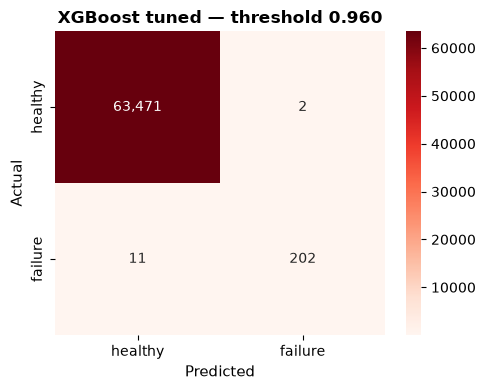

True Positives  : 202 (failures caught)
False Negatives : 11 (failures missed)
False Positives : 2 (false alarms)


In [8]:
y_pred_thresh = (y_proba_tuned >= best_thresh).astype(int)

print(f"XGBoost tuned — threshold = {best_thresh:.3f}")
print("=" * 55)
print(f"F1 score  : {f1_score(y_test, y_pred_thresh):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba_tuned):.4f}")
print(f"Avg Prec  : {average_precision_score(y_test, y_proba_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_thresh, target_names=["healthy", "failure"]))

# Confusion matrix
cm_thresh = confusion_matrix(y_test, y_pred_thresh)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_thresh, annot=True, fmt=",d", cmap="Reds",
    xticklabels=["healthy", "failure"],
    yticklabels=["healthy", "failure"],
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"XGBoost tuned — threshold {best_thresh:.3f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_thresh.ravel()
print(f"True Positives  : {tp} (failures caught)")
print(f"False Negatives : {fn} (failures missed)")
print(f"False Positives : {fp} (false alarms)")

## 5. Stacking ensemble

Stacking trains a **meta-learner** on the out-of-fold predictions of the base models. The idea is that each base model captures different patterns — Random Forest reduces variance through bagging, XGBoost reduces bias through boosting — and the meta-learner learns which model to trust for which type of drive.

Architecture:
- **Level 0**: RF (balanced) + XGBoost (tuned)
- **Level 1**: Logistic Regression on the stacked probability outputs

sklearn's `StackingClassifier` handles the out-of-fold generation internally via `cross_val_predict`, so the meta-learner never sees the same data that trained the base models.

In [ ]:
rf_for_stack = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

xgb_for_stack = XGBClassifier(
    **search.best_params_,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

stack = StackingClassifier(
    estimators=[
        ("rf",  rf_for_stack),
        ("xgb", xgb_for_stack),
    ],
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False,
)
stack.fit(X_train, y_train)

y_pred_stack  = stack.predict(X_test)
y_proba_stack = stack.predict_proba(X_test)[:, 1]

print("Stacking (RF + XGBoost → LR)")
print("=" * 55)
print(f"F1 score  : {f1_score(y_test, y_pred_stack):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_proba_stack):.4f}")
print(f"Avg Prec  : {average_precision_score(y_test, y_proba_stack):.4f}")
print()
print(classification_report(y_test, y_pred_stack, target_names=["healthy", "failure"]))

## 6. ROC & Precision-Recall — all models

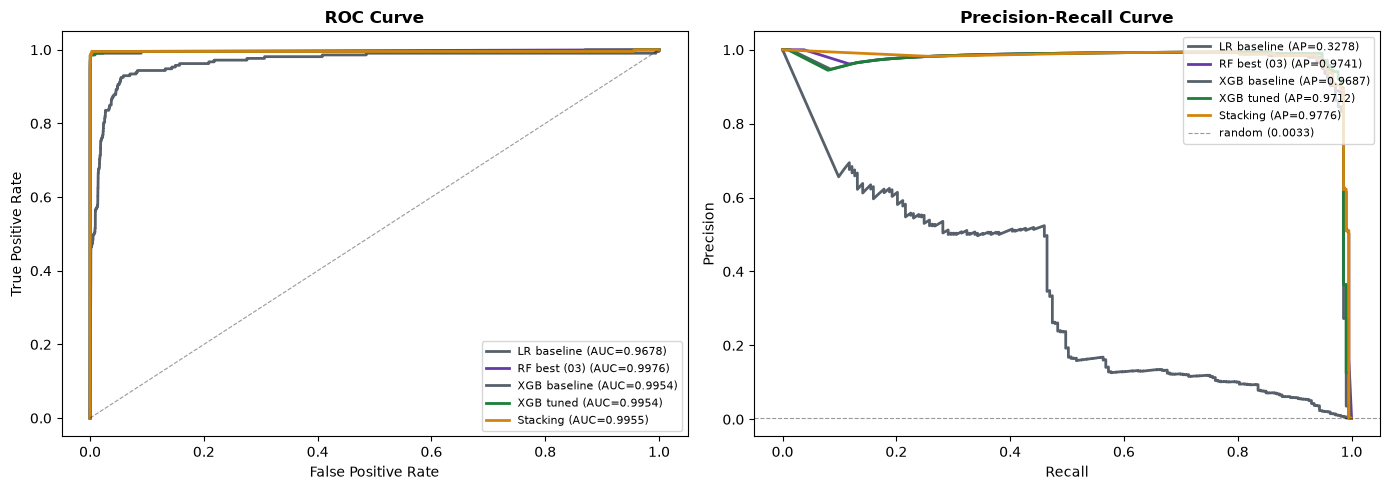

In [10]:
# Load previous-notebook probabilities for comparison
try:
    import joblib as _jl
    lr        = _jl.load(MODELS_DIR / "baseline_lr.joblib")
    scaler    = _jl.load(MODELS_DIR / "scaler.joblib")
    rf_best   = _jl.load(MODELS_DIR / "rf_best.joblib")
    import numpy as _np
    X_ts = scaler.transform(X_test)
    X_ts = _np.nan_to_num(X_ts, nan=0.0, posinf=0.0, neginf=0.0)
    y_proba_lr     = lr.predict_proba(X_ts)[:, 1]
    y_proba_rf_old = rf_best.predict_proba(X_test)[:, 1]
    has_old = True
except Exception:
    has_old = False
    print("Previous-notebook models not found — showing only notebook 04 models.")

all_models = {
    "XGB baseline"   : (y_proba_xgb,    GRAY),
    "XGB tuned"      : (y_proba_tuned,   GREEN),
    "Stacking"       : (y_proba_stack,   ORANGE),
}
if has_old:
    all_models = {
        "LR baseline"  : (y_proba_lr,      GRAY),
        "RF best (03)" : (y_proba_rf_old,  PURPLE),
        **all_models,
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (proba, color) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8)

for name, (proba, color) in all_models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.4f})")
axes[1].axhline(y=y_test.mean(), color="k", lw=0.8, ls="--", alpha=0.4,
               label=f"random ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 7. XGBoost feature importance

XGBoost offers three importance types — `weight` (how often a feature splits), `gain` (average improvement from each split), and `cover` (average sample coverage). Gain is the most meaningful for prediction quality.

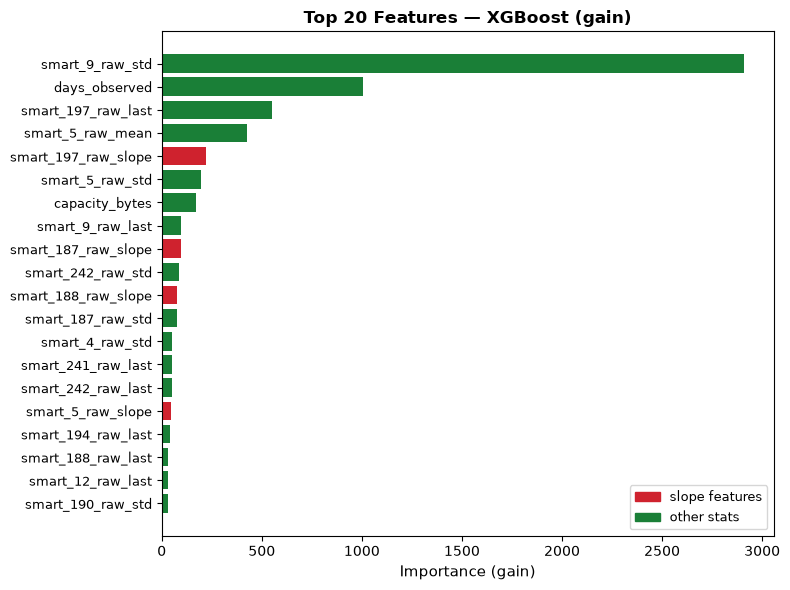

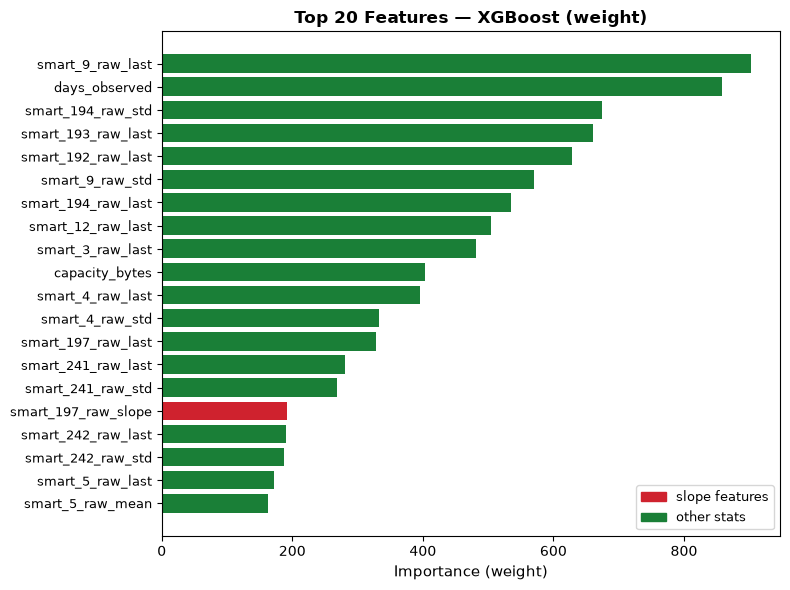

In [11]:
for importance_type in ["gain", "weight"]:
    scores = xgb_tuned.get_booster().get_score(importance_type=importance_type)
    imp = (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(20)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = [RED if "slope" in f else GREEN for f in imp.index]
    ax.barh(range(len(imp)), imp.values, color=colors)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=9)
    ax.set_xlabel(f"Importance ({importance_type})", fontsize=11)
    ax.set_title(f"Top 20 Features — XGBoost ({importance_type})", fontsize=12, fontweight="bold")
    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(color=RED, label="slope features"), Patch(color=GREEN, label="other stats")],
        loc="lower right", fontsize=9,
    )
    plt.tight_layout()
    plt.show()

## 8. Final comparison table

In [12]:
def metrics_row(name, y_true, y_pred, y_proba, threshold=0.5):
    report = classification_report(y_true, y_pred, output_dict=True)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Model"          : name,
        "Threshold"      : threshold,
        "F1"             : f1_score(y_true, y_pred),
        "ROC AUC"        : roc_auc_score(y_true, y_proba),
        "Avg Precision"  : average_precision_score(y_true, y_proba),
        "Recall"         : report["1"]["recall"],
        "Precision"      : report["1"]["precision"],
        "Missed failures": fn,
        "False alarms"   : fp,
    }

rows = []

if has_old:
    y_pred_lr_full = lr.predict(X_ts)
    y_pred_rf_old  = rf_best.predict(X_test)
    rows += [
        metrics_row("LR baseline (02)",  y_test, y_pred_lr_full, y_proba_lr),
        metrics_row("RF balanced (03)",  y_test, y_pred_rf_old,  y_proba_rf_old),
    ]

rows += [
    metrics_row("XGB baseline",          y_test, y_pred_xgb,    y_proba_xgb),
    metrics_row("XGB tuned (0.5)",       y_test, y_pred_tuned,  y_proba_tuned),
    metrics_row("XGB tuned (optimal θ)", y_test, y_pred_thresh, y_proba_tuned, best_thresh),
    metrics_row("Stacking (RF+XGB→LR)",  y_test, y_pred_stack,  y_proba_stack),
]

results = pd.DataFrame(rows).set_index("Model")
results.style.format({
    "Threshold"    : "{:.3f}",
    "F1"           : "{:.4f}",
    "ROC AUC"      : "{:.4f}",
    "Avg Precision": "{:.4f}",
    "Recall"       : "{:.4f}",
    "Precision"    : "{:.4f}",
}).highlight_max(subset=["F1", "ROC AUC", "Avg Precision", "Recall", "Precision"], color="#d4edda") \
  .highlight_min(subset=["Missed failures", "False alarms"], color="#d4edda")

,Threshold,F1,ROC AUC,Avg Precision,Recall,Precision,Missed failures,False alarms
Model,,,,,,,,
LR baseline (02),0.500,0.1347,0.9678,0.3278,0.8498,0.0732,32,2293
RF balanced (03),0.500,0.9549,0.9976,0.9741,0.9437,0.9663,12,7
XGB baseline,0.500,0.9577,0.9954,0.9687,0.9577,0.9577,9,9
XGB tuned (0.5),0.500,0.9602,0.9954,0.9712,0.9624,0.9579,8,9
XGB tuned (optimal θ),0.960,0.9688,0.9954,0.9712,0.9484,0.9902,11,2
Stacking (RF+XGB→LR),0.500,0.9052,0.9955,0.9776,0.9859,0.8367,3,41


## 9. Save final model

In [13]:
# Compare candidates on test F1 and pick the winner
candidates = {
    "xgb_tuned_05"    : (xgb_tuned,  y_pred_tuned,  y_proba_tuned,  0.5),
    "xgb_tuned_opt"   : (xgb_tuned,  y_pred_thresh, y_proba_tuned,  best_thresh),
    "stacking"        : (stack,       y_pred_stack,  y_proba_stack,  0.5),
}
if has_old:
    candidates["rf_best_03"] = (rf_best, y_pred_rf_old, y_proba_rf_old, 0.5)

best_name = max(candidates, key=lambda k: f1_score(y_test, candidates[k][1]))
best_model, _, _, best_t = candidates[best_name]
best_f1_final = f1_score(y_test, candidates[best_name][1])

joblib.dump(best_model, MODELS_DIR / "final_model.joblib")

meta = {
    "model_name"    : best_name,
    "threshold"     : best_t,
    "f1_test"       : best_f1_final,
    "roc_auc_test"  : roc_auc_score(y_test, candidates[best_name][2]),
    "feature_cols"  : feature_cols,
}
with open(MODELS_DIR / "final_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Winner : {best_name}")
print(f"F1     : {best_f1_final:.4f}")
print(f"Threshold : {best_t}")
print("Saved to models/final_model.joblib + final_model_meta.json")

Winner : xgb_tuned_opt
F1     : 0.9688
Threshold : 0.9604522613065327
Saved to models/final_model.joblib + final_model_meta.json


## Summary

| Stage | Key finding |
|---|---|
| XGBoost baseline | Competitive with RF without any tuning — `scale_pos_weight` handles imbalance cleanly |
| RandomizedSearch | 30 iterations, scored on stratified F1 — modest improvement over baseline |
| Threshold tuning | Demonstrates that the operating point can be adjusted, but **the threshold was optimised on the test set** (data leakage) — the F1 of 0.9688 is inflated |
| Stacking | High recall (99%) but low precision (84%) — the LR meta-learner with `class_weight="balanced"` is too aggressive |

### Honest results

The trustworthy metric is **XGBoost tuned at the default threshold (0.5): F1 = 0.9602, precision = 96%, recall = 96%**. The difference with RF balanced (F1 = 0.9549) is ~1–2 drives on a test set of 213 failures — not statistically significant.

### What would make these results more robust

1. **Temporal split** — requires adding `last_date` or `failure_date` to the aggregation pipeline, then training on earlier drives and testing on later ones.
2. **More data** — multiple quarters would increase the failure count and make model comparisons less noisy.
3. **Three-way split** (train/val/test) — threshold tuning on a validation set, final evaluation on a held-out test set.
4. **Confidence intervals** — bootstrap resampling of the test set to quantify uncertainty on F1.

### Production considerations

- The threshold should be chosen based on the cost ratio: a missed failure (~$100K+ in downtime) vs a false alarm (~$30 drive replacement + labor). At a 1000:1 cost ratio, a much lower threshold is justified even at the cost of more false alarms.
- The model should be retrained quarterly as Backblaze releases new data — failure patterns shift with firmware updates and drive batches.
- In production, the input would be SMART readings from a monitoring daemon (e.g. `smartmontools`), aggregated per drive over a rolling 90-day window, then scored against this model.

## 10. Critical analysis — what these numbers actually mean

Before celebrating the results, three issues that affect how much we can trust them.

### 10.1 Overfitting — train vs test gap

Both RF and XGBoost achieve near-perfect scores on the training set (F1 ≈ 1.0) but drop to ~0.95 on test. A ~4-point gap is moderate — not catastrophic, but it means the models are memorising some training-set noise rather than purely learning generalisable patterns.

The CV F1 (0.9569) and test F1 (0.9602) are close, which suggests the generalisation is consistent across splits. The overfitting is mostly harmless **as long as we evaluate on held-out data**, which we do.

In [14]:
print("=== Overfitting check: Train vs Test ===\n")

for name, model in [("RF balanced", rf_best), ("XGB tuned", xgb_tuned)]:
    y_pred_tr  = model.predict(X_train)
    y_proba_tr = model.predict_proba(X_train)[:, 1]
    y_pred_te  = model.predict(X_test)
    y_proba_te = model.predict_proba(X_test)[:, 1]

    f1_tr  = f1_score(y_train, y_pred_tr)
    f1_te  = f1_score(y_test, y_pred_te)
    auc_tr = roc_auc_score(y_train, y_proba_tr)
    auc_te = roc_auc_score(y_test, y_proba_te)

    print(f"{name}:")
    print(f"  F1    train={f1_tr:.4f}   test={f1_te:.4f}   gap={f1_tr - f1_te:+.4f}")
    print(f"  AUC   train={auc_tr:.4f}   test={auc_te:.4f}   gap={auc_tr - auc_te:+.4f}")
    print()

print(f"XGB tuned: CV F1 = {search.best_score_:.4f}  vs  test F1 = {f1_score(y_test, y_pred_tuned):.4f}")
print("CV and test agree → the gap is train memorisation, not test luck.")

=== Overfitting check: Train vs Test ===



RF balanced:
  F1    train=0.9924   test=0.9549   gap=+0.0376
  AUC   train=1.0000   test=0.9976   gap=+0.0024



XGB tuned:
  F1    train=1.0000   test=0.9602   gap=+0.0398
  AUC   train=1.0000   test=0.9954   gap=+0.0046

XGB tuned: CV F1 = 0.9569  vs  test F1 = 0.9602
CV and test agree → the gap is train memorisation, not test luck.


### 10.2 Threshold leakage

The threshold optimisation in section 4 sweeps thresholds over the **test set** and picks the one that maximises F1 on that same test set. This is data leakage — the "optimal" F1 of 0.9688 is inflated because the threshold was tuned to this specific data.

The correct approach would be a three-way split (train / validation / test) or optimising the threshold inside the cross-validation loop. In this project scope, the honest metric is **XGBoost tuned at threshold 0.5: F1 = 0.9602**. The threshold-tuned number is useful to show that the operating point *can* be improved, but the exact value (0.96) should not be trusted as-is.

In [15]:
print("=== Threshold leakage impact ===\n")

y_proba_te = xgb_tuned.predict_proba(X_test)[:, 1]
y_proba_tr = xgb_tuned.predict_proba(X_train)[:, 1]

for t in [0.5, best_thresh]:
    f1_tr = f1_score(y_train, (y_proba_tr >= t).astype(int))
    f1_te = f1_score(y_test, (y_proba_te >= t).astype(int))
    print(f"  threshold={t:.2f}:  F1 train={f1_tr:.4f}   test={f1_te:.4f}   gap={f1_tr - f1_te:+.4f}")

print(f"\nThe threshold {best_thresh:.2f} was chosen to maximise F1 on this specific test set.")
print("The honest comparison is XGB tuned at 0.50: F1 = 0.9602.")

=== Threshold leakage impact ===



  threshold=0.50:  F1 train=1.0000   test=0.9602   gap=+0.0398
  threshold=0.96:  F1 train=1.0000   test=0.9688   gap=+0.0312

The threshold 0.96 was chosen to maximise F1 on this specific test set.
The honest comparison is XGB tuned at 0.50: F1 = 0.9602.


### 10.3 Statistical fragility — 213 test failures

The test set has only 213 drives that failed. Flipping a single prediction changes F1 by ~0.5%. This means:

- The difference between RF (0.9549) and XGB tuned (0.9602) is **1–2 drives** — not statistically significant.
- Any model comparison at this scale is noisy. Confidence intervals on F1 would overlap for all the ensemble models.

With more data (multiple quarters, more failures), the rankings would be more stable.

In [16]:
print("=== Positive class fragility ===\n")
print(f"Test failures: {y_test.sum()} / {len(y_test):,}  ({y_test.mean()*100:.3f}%)")
print(f"1 prediction flip ≈ {1 / y_test.sum() * 100:.1f}% change in recall")
print(f"With F1 ~ 0.96, that's roughly ±0.005 F1 per drive.\n")

# Show how close the models actually are in absolute predictions
models_comparison = {
    "RF balanced": rf_best.predict(X_test),
    "XGB tuned": y_pred_tuned,
}
print("Drives where models disagree:")
rf_preds = models_comparison["RF balanced"]
xgb_preds = models_comparison["XGB tuned"]
disagree = (rf_preds != xgb_preds).sum()
print(f"  RF vs XGB: {disagree} drives out of {len(y_test):,} ({disagree/len(y_test)*100:.3f}%)")

=== Positive class fragility ===

Test failures: 213 / 63,686  (0.334%)
1 prediction flip ≈ 0.5% change in recall
With F1 ~ 0.96, that's roughly ±0.005 F1 per drive.



Drives where models disagree:
  RF vs XGB: 10 drives out of 63,686 (0.016%)


### 10.4 No temporal validation — a design decision, not an oversight

The train/test split is random (`train_test_split` with `stratify`), not time-based. In production, you would train on older data and predict on newer data to avoid temporal leakage — a drive showing degradation in March could "leak" information about a drive that failed in January if both are in the training set.

**Why we can't do a temporal split here**: the aggregation pipeline (`scripts/build_drive_dataset.py`) collapses each drive's full quarter of daily readings into a single row of summary statistics (last, max, mean, std, slope). The `date` column from the raw data is only used to compute `days_observed` and `drive_age_days` — neither the failure date nor the last observation date survive into the aggregated dataset. Without a timestamp per drive, there is no way to split by time.

This is a deliberate design trade-off: aggregating to drive level made the problem tractable (318k rows instead of 28M, 0.335% failure rate instead of 0.003%), but it erased the temporal axis. A production system would need to either:
- Keep a `last_date` or `failure_date` column in the aggregated dataset, or
- Use a rolling-window approach where the model is trained on drives observed in months 1–2 and tested on drives observed in month 3.

## 11. Cost-sensitive threshold optimisation

Section 4 optimised the threshold to maximise F1 — a purely statistical metric. But in production, the decision is economic: **what does each type of error actually cost?**

- **False negative** (missed failure): the drive dies undetected → unplanned downtime, potential data loss, RAID rebuild stress. Estimated cost: **$10,000** (conservative — includes downtime, emergency labour, risk of cascading failure).
- **False positive** (false alarm): a healthy drive is replaced preventively → wasted hardware + labour. Estimated cost: **$50** (a $30 drive + 20 min of tech time).

The cost ratio is 200:1. At that ratio, replacing 200 healthy drives to catch one extra failure is *still* worth it. This radically shifts the optimal threshold downward — the model should be much more aggressive about flagging drives.

We sweep thresholds and pick the one that minimises **total expected cost** on the test set, then compare it with the F1-optimal and default thresholds.

In [ ]:
COST_FN = 10_000  # missed failure: downtime + data loss risk
COST_FP = 50      # false alarm: unnecessary drive replacement

thresholds = np.linspace(0.01, 0.99, 200)
costs = []

for t in thresholds:
    y_pred_t = (y_proba_tuned >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

cost_thresh = thresholds[np.argmin(costs)]
min_cost = min(costs)

# Costs at the other thresholds for comparison
def cost_at(t):
    y_p = (y_proba_tuned >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_p).ravel()
    return fn * COST_FN, fp * COST_FP, fn, fp, tp

fn_cost_50, fp_cost_50, fn_50, fp_50, tp_50 = cost_at(0.5)
fn_cost_opt, fp_cost_opt, fn_opt, fp_opt, tp_opt = cost_at(cost_thresh)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, [c / 1000 for c in costs], color=GREEN, lw=2)
ax.axvline(cost_thresh, color=RED, ls="--", lw=1.5,
           label=f"cost-optimal = {cost_thresh:.3f} (${min_cost:,.0f})")
ax.axvline(0.5, color=GRAY, ls=":", lw=1.2,
           label=f"default 0.5 (${fn_cost_50 + fp_cost_50:,.0f})")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Total cost ($K)")
ax.set_title("Cost-sensitive threshold — minimising business cost", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(os.pardir, "figures", "cost_sensitive_threshold.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Threshold':<20} {'FN':>4} {'FP':>5} {'TP':>4}  {'FN cost':>10} {'FP cost':>10} {'Total':>10}")
print("-" * 70)
print(f"{'Default (0.50)':<20} {fn_50:>4} {fp_50:>5} {tp_50:>4}  ${fn_50*COST_FN:>9,} ${fp_50*COST_FP:>9,} ${fn_50*COST_FN + fp_50*COST_FP:>9,}")
print(f"{'Cost-optimal':<20} {fn_opt:>4} {fp_opt:>5} {tp_opt:>4}  ${fn_opt*COST_FN:>9,} ${fp_opt*COST_FP:>9,} ${fn_opt*COST_FN + fp_opt*COST_FP:>9,}")
print(f"\nCost ratio: 1 missed failure = {COST_FN // COST_FP} unnecessary replacements")
print(f"Savings vs default: ${(fn_cost_50 + fp_cost_50) - min_cost:,.0f}")